# Predicting Customer Repeat Purchase Behavior in E-Commerce

**Business Analytics Individual Case Study — Final Analysis Notebook**

### Business problem
Online retailers need to understand which customer characteristics are associated with repeat purchasing instead of relying only on blanket discounting.

### Business objective
1. Identify behavioral, satisfaction-related, spending and demographic factors associated with repeat purchase behavior.
2. Build classification models to estimate the likelihood of repeat purchase.
3. Compare **satisfaction-related factors** with **discount/spending-related factors** using the same evaluation framework.
4. Translate the statistical/modeling results into actionable business insights.

> **Important interpretation:** this is an observational survey. The analysis identifies associations and predictive usefulness; it does **not** establish causal effects.

In [1]:
# 1. Imports and analysis settings
import os, glob, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
TEST_SIZE = 0.20
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

## 2. Load the survey dataset

The notebook is designed for GitHub/Jupyter reproducibility. Put the Excel file in `data/E-Commerce Survey.xlsx`.

In [2]:
data_path = "data/E-Commerce Survey.xlsx"

if not os.path.exists(data_path):
    raise FileNotFoundError(
        f"Dataset not found at '{data_path}'. "
        "Make sure the Excel file is inside the data/ folder."
    )

raw = pd.read_excel(data_path)

print("Dataset loaded successfully.")
print("Shape:", raw.shape)
print("Raw shape:", raw.shape)
raw.head(5)


Dataset loaded successfully.
Shape: (11401, 14)
Raw shape: (11401, 14)


,Timestamp,"Have you shopped on an e-commerce platform (Amazon, Flipkart, Myntra, etc.) in the last 6 months?",Have you purchased from the same e-commerce platform more than once in the last 12 months?,"On average, how many times do you shop online per month?",Which platform do you shop on most often?,How satisfied are you with delivery speed?,How satisfied are you that products match their description/photos?,How important are discounts/offers in your decision to purchase?,How would you rate the app/website's ease of use?,Have you ever faced a return/refund issue on any platform?,Age,Occupation,Monthly spending capacity on online shopping,What is your average order value (per purchase)?
0,2026-07-10 14:39:43.290000,Yes,Yes,1 - 2,Amazon,3.0000,4.0000,2.0000,5.0000,Yes,18–24,Student,₹1000–₹5000,₹500–₹1500
1,2026-07-11 10:59:57.412000,Yes,Yes,Less than 1,Amazon,4.0000,5.0000,2.0000,4.0000,No,18–24,Student,₹1000–₹5000,₹1500–₹3000
2,2026-07-11 11:01:25.651000,Yes,No,1 - 2,Blinkit,4.0000,4.0000,5.0000,4.0000,Yes,18–24,Student,Below ₹1000,Below ₹500
3,2026-07-11 11:05:35.665000,Yes,Yes,1 - 2,Amazon,4.0000,3.0000,2.0000,4.0000,Yes,18–24,Self-employed,₹1000–₹5000,₹1500–₹3000
4,2026-07-11 11:06:03.482000,Yes,No,1 - 2,Amazon,4.0000,1.0000,4.0000,5.0000,Yes,18–24,Student,₹1000–₹5000,Above ₹3000


## 3. Dataset Overview

The dataset was collected through a questionnaire using Google Forms. The collected responses contain demographic, shopping behavior, satisfaction, spending, and repeat-purchase information.

The dataset is first inspected for its dimensions, data types, missing values, and duplicate records before further analysis.

In [3]:
print("Number of rows:", raw.shape[0])
print("Number of columns:", raw.shape[1])

print("\nData types:")
display(raw.dtypes)

print("\nMissing values:")
display(raw.isnull().sum())

print("\nDuplicate rows:", raw.duplicated().sum())

Number of rows: 11401
Number of columns: 14

Data types:


Timestamp                                                                                              object
Have you shopped on an e-commerce platform (Amazon, Flipkart, Myntra, etc.) in the last 6 months?         str
Have you purchased from the same e-commerce platform more than once in the last 12 months?                str
On average, how many times do you shop online per month?                                                  str
Which platform do you shop on most often?                                                                 str
How satisfied are you with delivery speed?                                                            float64
How satisfied are you that products match their description/photos?                                   float64
How important are discounts/offers in your decision to purchase?                                      float64
How would you rate the app/website's ease of use?                                                     float64
Have you e


Missing values:


Timestamp                                                                                                0
Have you shopped on an e-commerce platform (Amazon, Flipkart, Myntra, etc.) in the last 6 months?        0
Have you purchased from the same e-commerce platform more than once in the last 12 months?            5240
On average, how many times do you shop online per month?                                              5240
Which platform do you shop on most often?                                                             5240
How satisfied are you with delivery speed?                                                            5240
How satisfied are you that products match their description/photos?                                   5240
How important are discounts/offers in your decision to purchase?                                      5240
How would you rate the app/website's ease of use?                                                     5240
Have you ever faced a return/refund i


Duplicate rows: 1


## 4. Data understanding and cleaning

The survey contains 14 columns including the timestamp. The survey uses skip logic: respondents who did not shop online in the last six months do not have responses to the downstream shopper questions. Therefore, they are not treated as ordinary missing-value records for the repeat-purchase model; they are outside the modeling population.

In [4]:
# Clean column names and string responses
raw.columns = [c.strip() for c in raw.columns]
df = raw.copy()

for c in df.select_dtypes(include="object").columns:
    df[c] = df[c].astype(str).str.strip().replace({"nan": np.nan})

before = len(df)
df = df.drop_duplicates().copy()
print(f"Exact duplicate rows removed: {before - len(df)}")
print(f"Cleaned dataset shape: {df.shape}")
print("Rows before duplicate removal:", len(raw))
print("Duplicate rows removed:", raw.duplicated().sum())
print("Rows after duplicate removal:", len(df))

# Rename columns to concise analysis names
rename_map = {
    'Timestamp': 'timestamp',
    'Have you shopped on an e-commerce platform (Amazon, Flipkart, Myntra, etc.) in the last 6 months?': 'shopped_last_6m',
    'Have you purchased from the same e-commerce platform more than once in the last 12 months?': 'repeat_purchase',
    'On average, how many times do you shop online per month?': 'shop_freq_month',
    'Which platform do you shop on most often?': 'platform',
    'How satisfied are you with delivery speed?': 'sat_delivery',
    'How satisfied are you that products match their description/photos?': 'sat_product_match',
    'How important are discounts/offers in your decision to purchase?': 'discount_importance',
    "How would you rate the app/website's ease of use?": 'sat_ease_of_use',
    'Have you ever faced a return/refund issue on any platform?': 'return_issue',
    'Age': 'age_band',
    'Occupation': 'occupation',
    'Monthly spending capacity on online shopping': 'monthly_spend_capacity',
    'What is your average order value (per purchase)?': 'avg_order_value'
}
df = df.rename(columns=rename_map)

print("\nColumn names after cleaning:")
print(df.columns.tolist())
print("\nMissing values:")
display(df.isna().sum().to_frame("missing_count"))

Exact duplicate rows removed: 1
Cleaned dataset shape: (11400, 14)
Rows before duplicate removal: 11401
Duplicate rows removed: 1
Rows after duplicate removal: 11400

Column names after cleaning:
['timestamp', 'shopped_last_6m', 'repeat_purchase', 'shop_freq_month', 'platform', 'sat_delivery', 'sat_product_match', 'discount_importance', 'sat_ease_of_use', 'return_issue', 'age_band', 'occupation', 'monthly_spend_capacity', 'avg_order_value']

Missing values:


,missing_count
timestamp,0
shopped_last_6m,0
repeat_purchase,5239
shop_freq_month,5239
platform,5239
sat_delivery,5239
sat_product_match,5239
discount_importance,5239
sat_ease_of_use,5239
return_issue,5239


## 5. Define the modeling population and target

The model is intended to predict repeat purchase among respondents who actually shopped online in the last six months. The target is:

- **Yes → 1:** purchased from the same platform more than once in the last 12 months
- **No → 0:** did not purchase from the same platform more than once

The timestamp is not used as a predictor.

In [5]:
# Scope the model to respondents who answered the shopper questions
shoppers = df[df["shopped_last_6m"].eq("Yes")].copy()

# Binary target
shoppers["target"] = shoppers["repeat_purchase"].str.lower().map({"yes": 1, "no": 0})

# Remove rows with an invalid target, if any
shoppers = shoppers.dropna(subset=["target"]).copy()
shoppers["target"] = shoppers["target"].astype(int)

print("Total respondents:", len(df))
print("Shoppers in the last 6 months:", len(shoppers))
print("Non-shoppers excluded:", len(df) - len(shoppers))
print(f"Non-shoppers in last 6 months: {(df['shopped_last_6m'] == 'No').sum():,}")
print(f"Usable shopper responses: {len(shoppers):,}")
print(f"Repeat purchase = Yes: {shoppers['target'].sum():,} ({shoppers['target'].mean()*100:.2f}%)")
print(f"Repeat purchase = No: {(1-shoppers['target']).sum():,} ({(1-shoppers['target'].mean())*100:.2f}%)")
print("\nRepeat purchase distribution:")
display(shoppers["repeat_purchase"].value_counts())
display(shoppers["repeat_purchase"].value_counts(normalize=True) * 100)

Total respondents: 11400
Shoppers in the last 6 months: 6161
Non-shoppers excluded: 5239
Non-shoppers in last 6 months: 5,239
Usable shopper responses: 6,161
Repeat purchase = Yes: 3,125 (50.72%)
Repeat purchase = No: 3,036 (49.28%)

Repeat purchase distribution:


repeat_purchase
Yes    3125
No     3036
Name: count, dtype: int64

repeat_purchase
Yes   50.7223
No    49.2777
Name: proportion, dtype: float64

## 6. Exploratory Data Analysis

EDA is used to understand the target distribution and identify visible relationships before modeling.

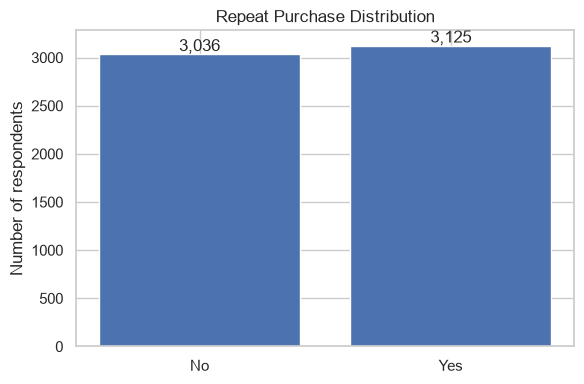

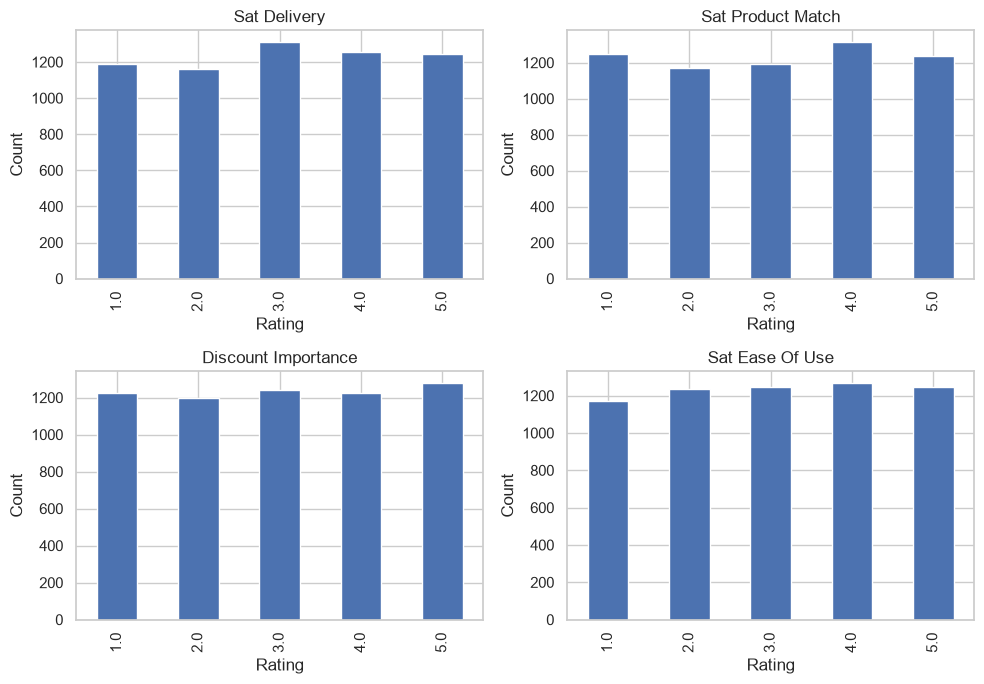

In [6]:
# Target distribution
fig, ax = plt.subplots(figsize=(6,4))
counts = shoppers["target"].value_counts().sort_index()
ax.bar(["No", "Yes"], counts.values)
ax.set_title("Repeat Purchase Distribution")
ax.set_ylabel("Number of respondents")
for i, v in enumerate(counts.values):
    ax.text(i, v + max(counts.values)*0.01, f"{v:,}", ha="center")
plt.tight_layout()
plt.show()

# Satisfaction / discount distributions
survey_numeric = ["sat_delivery", "sat_product_match", "discount_importance", "sat_ease_of_use"]
fig, axes = plt.subplots(2, 2, figsize=(10,7))
for ax, col in zip(axes.ravel(), survey_numeric):
    shoppers[col].value_counts().sort_index().plot(kind="bar", ax=ax)
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("Rating")
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

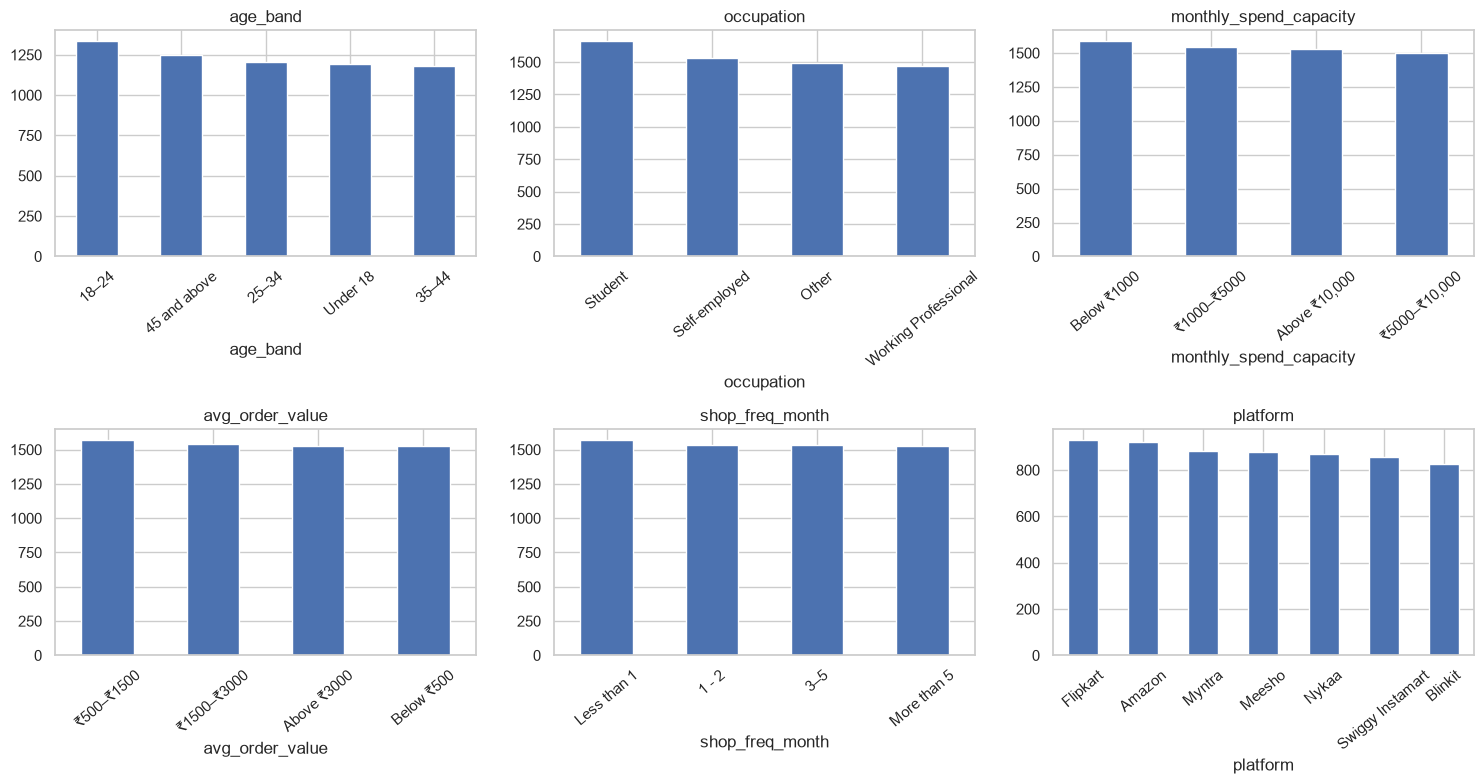

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
cat_cols = ['age_band', 'occupation', 'monthly_spend_capacity', 'avg_order_value', 'shop_freq_month', 'platform']
for ax, col in zip(axes.flat, cat_cols):
    order = shoppers[col].value_counts().index
    shoppers[col].value_counts().loc[order].plot.bar(ax=ax, color='#4C72B0')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=40)
plt.tight_layout()
plt.savefig('fig_demographics.png', dpi=110)
plt.show()


In [8]:
# Repeat-purchase rate by important categorical dimensions

def repeat_rate_table(column):
    out = shoppers.groupby(column)["target"].agg(
        respondents="count",
        repeat_purchases="sum",
        repeat_rate="mean"
    ).sort_values("repeat_rate", ascending=False)
    out["repeat_rate"] = out["repeat_rate"] * 100
    return out

print("Repeat-purchase rate by shopping frequency:")
display(repeat_rate_table("shop_freq_month"))

print("Repeat-purchase rate by preferred platform:")
display(repeat_rate_table("platform"))

print("Repeat-purchase rate by return/refund experience:")
display(repeat_rate_table("return_issue"))

Repeat-purchase rate by shopping frequency:


,respondents,repeat_purchases,repeat_rate
shop_freq_month,,,
1 - 2,1537,812,52.8302
Less than 1,1569,794,50.6055
3–5,1532,766,50.0000
More than 5,1523,753,49.4419


Repeat-purchase rate by preferred platform:


,respondents,repeat_purchases,repeat_rate
platform,,,
Amazon,919,486,52.8836
Blinkit,827,428,51.7533
Flipkart,929,479,51.5608
Swiggy Instamart,855,430,50.2924
Nykaa,870,432,49.6552
Myntra,881,437,49.6027
Meesho,880,433,49.2045


Repeat-purchase rate by return/refund experience:


,respondents,repeat_purchases,repeat_rate
return_issue,,,
Yes,3096,1571,50.7429
No,3065,1554,50.7015


In [9]:
# Satisfaction and discount variables by target class
compare_cols = [
    "sat_delivery", "sat_product_match", "discount_importance", "sat_ease_of_use"
]
summary = shoppers.groupby("target")[compare_cols].mean().T
summary.columns = ["No Repeat", "Repeat"]
summary["Difference (Repeat - No Repeat)"] = summary["Repeat"] - summary["No Repeat"]
display(summary.sort_values("Difference (Repeat - No Repeat)", ascending=False))

,No Repeat,Repeat,Difference (Repeat - No Repeat)
sat_ease_of_use,2.9974,3.0592,0.0618
discount_importance,2.9980,3.0442,0.0461
sat_product_match,3.0020,3.0349,0.0329
sat_delivery,3.0408,3.0237,-0.0172


## 7. Statistical association checks

Before classification, simple statistical tests are used as supporting evidence. These tests are **not** treated as proof of causation. They answer whether the observed distributions differ between repeat and non-repeat groups in this sample.

- **Mann–Whitney U:** ordinal/numeric survey ratings.
- **Chi-square test + Cramer's V:** categorical variables.

Because multiple variables are tested, the results are presented as supporting evidence rather than as standalone causal conclusions.

In [10]:
from scipy.stats import mannwhitneyu, chi2_contingency

# Mann–Whitney U for ordinal survey ratings
ordinal_cols = ["sat_delivery", "sat_product_match", "discount_importance", "sat_ease_of_use"]
stat_rows = []
for col in ordinal_cols:
    a = shoppers.loc[shoppers["target"] == 1, col].dropna()
    b = shoppers.loc[shoppers["target"] == 0, col].dropna()
    u, pval = mannwhitneyu(a, b, alternative="two-sided")
    stat_rows.append({"Variable": col, "Test": "Mann-Whitney U", "Statistic": u, "p-value": pval})

# Chi-square + Cramer's V for categorical variables
categorical_test_cols = ["shop_freq_month", "platform", "return_issue", "age_band", "occupation", "monthly_spend_capacity", "avg_order_value"]
for col in categorical_test_cols:
    table = pd.crosstab(shoppers[col], shoppers["target"])
    chi2, pval, dof, expected = chi2_contingency(table)
    n = table.to_numpy().sum()
    r, k = table.shape
    cramer_v = np.sqrt((chi2 / n) / max(1, min(r - 1, k - 1)))
    stat_rows.append({"Variable": col, "Test": "Chi-square", "Statistic": chi2, "p-value": pval, "Cramer's V": cramer_v})

association_results = pd.DataFrame(stat_rows)
association_results["Significant at 5%"] = association_results["p-value"] < 0.05

display(association_results.sort_values("p-value"))

,Variable,Test,Statistic,p-value,Cramer's V,Significant at 5%
7,age_band,Chi-square,8.5369,0.0738,0.0372,False
8,occupation,Chi-square,6.7994,0.0786,0.0332,False
3,sat_ease_of_use,Mann-Whitney U,4861616.5000,0.0848,NaN,False
10,avg_order_value,Chi-square,4.8133,0.1860,0.0280,False
9,monthly_spend_capacity,Chi-square,4.7500,0.1910,0.0278,False
2,discount_importance,Mann-Whitney U,4831093.0000,0.2015,NaN,False
4,shop_freq_month,Chi-square,4.0595,0.2551,0.0257,False
1,sat_product_match,Mann-Whitney U,4808876.0000,0.3409,NaN,False
0,sat_delivery,Mann-Whitney U,4713786.5000,0.6613,NaN,False
5,platform,Chi-square,4.0429,0.6709,0.0256,False


## 8. Feature engineering and leakage-safe preprocessing

Three feature sets are evaluated:

1. **All features** — behavioral, satisfaction, discount/spending and demographic variables.
2. **Satisfaction group** — delivery satisfaction, product-description accuracy, ease of use and return/refund experience.
3. **Discount/spending group** — discount importance, monthly spending capacity and average order value.

The same train/test split and evaluation metrics are used for all groups, making the comparison fair. Preprocessing is fitted only on the training data through scikit-learn pipelines.

In [11]:
# Predictor columns
all_features = [
    "shop_freq_month", "platform", "sat_delivery", "sat_product_match",
    "discount_importance", "sat_ease_of_use", "return_issue", "age_band",
    "occupation", "monthly_spend_capacity", "avg_order_value"
]

satisfaction_features = [
    "sat_delivery", "sat_product_match", "sat_ease_of_use", "return_issue"
]

discount_features = [
    "discount_importance", "monthly_spend_capacity", "avg_order_value"
]

# Verify all expected variables exist
for group_name, cols in {
    "all": all_features,
    "satisfaction": satisfaction_features,
    "discount": discount_features
}.items():
    missing = [c for c in cols if c not in shoppers.columns]
    if missing:
        raise KeyError(f"Missing columns in {group_name} feature group: {missing}")

X_all = shoppers[all_features].copy()
y = shoppers["target"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")

Training rows: 4,928
Test rows: 1,233


In [12]:
# Build a reusable preprocessing + model pipeline

def make_preprocessor(X):
    numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
    categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    return ColumnTransformer([
        ("num", numeric_pipe, numeric_features),
        ("cat", categorical_pipe, categorical_features)
    ])


def make_models(X):
    preprocessor = make_preprocessor(X)
    return {
        "Logistic Regression": Pipeline([
            ("preprocessor", preprocessor),
            ("classifier", LogisticRegression(max_iter=2000, class_weight=None, random_state=RANDOM_STATE))
        ]),
        "Random Forest": Pipeline([
            ("preprocessor", preprocessor),
            ("classifier", RandomForestClassifier(
                n_estimators=400,
                max_depth=None,
                min_samples_leaf=3,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ])
    }

In [13]:
## Majority-class baseline

majority_class = y_train.mode()[0]
baseline_pred = np.full(len(y_test), majority_class)

baseline_accuracy = accuracy_score(y_test, baseline_pred)

print(f"Majority-class baseline accuracy: {baseline_accuracy:.4f}")

Majority-class baseline accuracy: 0.5069


### Baseline Comparison

The majority-class baseline achieved an accuracy of 50.69%. The cross-validated Logistic Regression and Random Forest models achieved mean accuracies of approximately 50.06% and 50.87%, respectively. Their mean ROC-AUC values were 0.506 and 0.516.

These results indicate that the models provide limited improvement over a simple baseline and should not currently be considered production-ready retention prediction systems.

## 9. Classification modeling and evaluation

The two models serve complementary purposes:

- **Logistic Regression:** interpretable baseline for estimating the direction and strength of linear associations.
- **Random Forest:** captures non-linear relationships and interactions without requiring a linear functional form.

Evaluation uses **Accuracy, Precision, Recall, F1 Score and ROC-AUC**. Because the target is close to balanced, accuracy is useful, but F1 and ROC-AUC are also reported to avoid relying on one metric.

In [14]:
def evaluate_feature_group(feature_cols, group_name):
    X = shoppers[feature_cols].copy()
    X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
    )

    models = make_models(X)
    rows = []
    fitted = {}
    predictions = {}

    for name, model in models.items():
        model.fit(X_train_g, y_train_g)
        pred = model.predict(X_test_g)
        prob = model.predict_proba(X_test_g)[:,1]
        fitted[name] = model
        predictions[name] = (pred, prob, X_test_g, y_test_g)
        rows.append({
            "Feature Group": group_name,
            "Model": name,
            "Accuracy": accuracy_score(y_test_g, pred),
            "Precision": precision_score(y_test_g, pred, zero_division=0),
            "Recall": recall_score(y_test_g, pred, zero_division=0),
            "F1 Score": f1_score(y_test_g, pred, zero_division=0),
            "ROC-AUC": roc_auc_score(y_test_g, prob)
        })

    return pd.DataFrame(rows), fitted, predictions

all_results, all_models, all_predictions = evaluate_feature_group(all_features, "All features")
sat_results, sat_models, sat_predictions = evaluate_feature_group(satisfaction_features, "Satisfaction")
disc_results, disc_models, disc_predictions = evaluate_feature_group(discount_features, "Discount / Spending")

model_results = pd.concat([all_results, sat_results, disc_results], ignore_index=True)
display(model_results.sort_values(["Model", "ROC-AUC"], ascending=[True, False]))

,Feature Group,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Satisfaction,Logistic Regression,0.5264,0.5224,0.7648,0.6208,0.5282
0,All features,Logistic Regression,0.5077,0.5132,0.5600,0.5356,0.5139
4,Discount / Spending,Logistic Regression,0.5004,0.5058,0.6240,0.5587,0.5036
1,All features,Random Forest,0.5434,0.5500,0.5456,0.5478,0.5437
5,Discount / Spending,Random Forest,0.5199,0.5231,0.5968,0.5575,0.5274
3,Satisfaction,Random Forest,0.4988,0.5059,0.4784,0.4918,0.5018


In [15]:
# Cross-validation on the full feature set for a more stable estimate
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []

for name, model in make_models(X_all).items():
    scores = cross_validate(
        model, X_all, y, cv=cv,
        scoring={"accuracy":"accuracy", "precision":"precision", "recall":"recall", "f1":"f1", "roc_auc":"roc_auc"},
        n_jobs=-1
    )
    cv_rows.append({
        "Model": name,
        "CV Accuracy Mean": scores["test_accuracy"].mean(),
        "CV Accuracy SD": scores["test_accuracy"].std(),
        "CV F1 Mean": scores["test_f1"].mean(),
        "CV F1 SD": scores["test_f1"].std(),
        "CV ROC-AUC Mean": scores["test_roc_auc"].mean(),
        "CV ROC-AUC SD": scores["test_roc_auc"].std()
    })

cv_results = pd.DataFrame(cv_rows)
display(cv_results)

,Model,CV Accuracy Mean,CV Accuracy SD,CV F1 Mean,CV F1 SD,CV ROC-AUC Mean,CV ROC-AUC SD
0,Logistic Regression,0.5006,0.0109,0.5275,0.0188,0.5056,0.0198
1,Random Forest,0.5087,0.0121,0.5222,0.0111,0.5164,0.0170


## 10. Confusion matrices and ROC curves

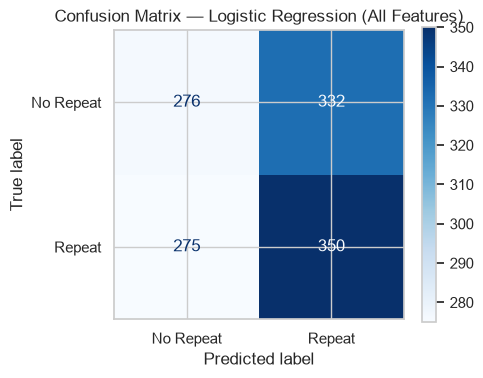

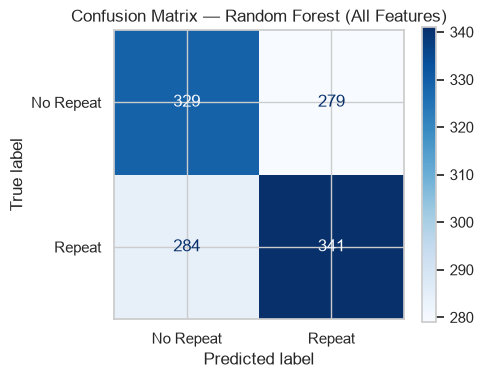

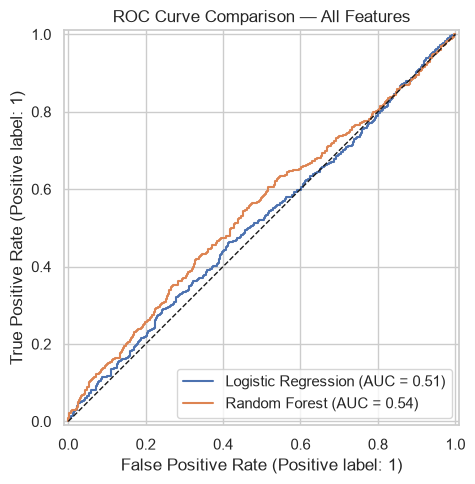

In [16]:
# Confusion matrices for the two all-feature models
for name, (pred, prob, Xte, yte) in all_predictions.items():
    fig, ax = plt.subplots(figsize=(5,4))
    ConfusionMatrixDisplay.from_predictions(
        yte, pred, display_labels=["No Repeat", "Repeat"], cmap="Blues", ax=ax
    )
    ax.set_title(f"Confusion Matrix — {name} (All Features)")
    plt.tight_layout()
    plt.show()

# ROC comparison for all-feature models
fig, ax = plt.subplots(figsize=(7,5))
for name, (pred, prob, Xte, yte) in all_predictions.items():
    RocCurveDisplay.from_predictions(yte, prob, name=name, ax=ax)
ax.plot([0,1], [0,1], "k--", linewidth=1)
ax.set_title("ROC Curve Comparison — All Features")
plt.tight_layout()
plt.show()

## 11. Feature importance and model interpretation

Random Forest impurity importance can be biased toward some variable types. Therefore, the main interpretation uses **permutation importance on the held-out test set**, which measures how much model performance changes when a feature is randomly shuffled.

This is still a predictive interpretation, not a causal effect.

,Feature,Mean ROC-AUC Importance,SD
7,age_band,0.0199,0.0075
3,sat_product_match,0.0184,0.0062
8,occupation,0.0170,0.0061
1,platform,0.0170,0.0096
2,sat_delivery,0.0093,0.0068
5,sat_ease_of_use,0.0047,0.0060
10,avg_order_value,0.0042,0.0104
9,monthly_spend_capacity,0.0033,0.0069
6,return_issue,0.0011,0.0059
0,shop_freq_month,-0.0006,0.0100


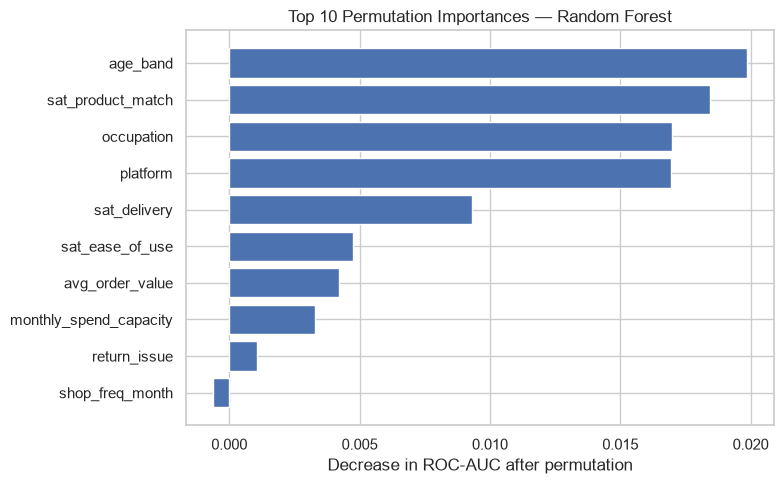

In [17]:
# Permutation importance for the all-feature Random Forest
rf_all = all_models["Random Forest"]
X_test_all = all_predictions["Random Forest"][2]
y_test_all = all_predictions["Random Forest"][3]

perm = permutation_importance(
    rf_all, X_test_all, y_test_all,
    n_repeats=15, random_state=RANDOM_STATE, scoring="roc_auc", n_jobs=-1
)

perm_table = pd.DataFrame({
    "Feature": X_test_all.columns,
    "Mean ROC-AUC Importance": perm.importances_mean,
    "SD": perm.importances_std
}).sort_values("Mean ROC-AUC Importance", ascending=False)

display(perm_table)

plot_table = perm_table.head(10).sort_values("Mean ROC-AUC Importance")
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(plot_table["Feature"], plot_table["Mean ROC-AUC Importance"])
ax.set_title("Top 10 Permutation Importances — Random Forest")
ax.set_xlabel("Decrease in ROC-AUC after permutation")
plt.tight_layout()
plt.show()

## 12. Direct comparison: satisfaction vs discount/spending

The key business question is not simply which individual variable has the largest importance. It is whether the **satisfaction feature group** or the **discount/spending feature group** provides more predictive information when evaluated under the same modeling procedure.

In [18]:
comparison = model_results.pivot_table(
    index="Model", columns="Feature Group", values=["F1 Score", "ROC-AUC", "Accuracy"]
)
display(comparison)

# Compact comparison for the business question
business_comparison = model_results[["Feature Group", "Model", "F1 Score", "ROC-AUC"]].copy()
business_comparison = business_comparison.sort_values(["Model", "ROC-AUC"], ascending=[True, False])
display(business_comparison)

Accuracy                                   \
Feature Group       All features Discount / Spending Satisfaction   
Model                                                               
Logistic Regression       0.5077              0.5004       0.5264   
Random Forest             0.5434              0.5199       0.4988   

                        F1 Score                                   \
Feature Group       All features Discount / Spending Satisfaction   
Model                                                               
Logistic Regression       0.5356              0.5587       0.6208   
Random Forest             0.5478              0.5575       0.4918   

                         ROC-AUC                                   
Feature Group       All features Discount / Spending Satisfaction  
Model                                                              
Logistic Regression       0.5139              0.5036       0.5282  
Random Forest             0.5437              0.5274       0.5018

,Feature Group,Model,F1 Score,ROC-AUC
2,Satisfaction,Logistic Regression,0.6208,0.5282
0,All features,Logistic Regression,0.5356,0.5139
4,Discount / Spending,Logistic Regression,0.5587,0.5036
1,All features,Random Forest,0.5478,0.5437
5,Discount / Spending,Random Forest,0.5575,0.5274
3,Satisfaction,Random Forest,0.4918,0.5018


## 13. Business insight tables

These descriptive tables provide interpretable context alongside the machine-learning results. They should be reported as **associations**, not causal effects.

In [19]:
# Top/bottom repeat-rate categories for selected variables
for col in ["shop_freq_month", "platform", "return_issue", "age_band", "occupation"]:
    print(f"\n{col.replace('_',' ').title()}")
    display(repeat_rate_table(col))


Shop Freq Month


,respondents,repeat_purchases,repeat_rate
shop_freq_month,,,
1 - 2,1537,812,52.8302
Less than 1,1569,794,50.6055
3–5,1532,766,50.0000
More than 5,1523,753,49.4419



Platform


,respondents,repeat_purchases,repeat_rate
platform,,,
Amazon,919,486,52.8836
Blinkit,827,428,51.7533
Flipkart,929,479,51.5608
Swiggy Instamart,855,430,50.2924
Nykaa,870,432,49.6552
Myntra,881,437,49.6027
Meesho,880,433,49.2045



Return Issue


,respondents,repeat_purchases,repeat_rate
return_issue,,,
Yes,3096,1571,50.7429
No,3065,1554,50.7015



Age Band


,respondents,repeat_purchases,repeat_rate
age_band,,,
18–24,1334,709,53.1484
25–34,1203,627,52.1197
45 and above,1249,634,50.7606
35–44,1183,582,49.1970
Under 18,1192,573,48.0705



Occupation


,respondents,repeat_purchases,repeat_rate
occupation,,,
Student,1661,879,52.9199
Working Professional,1471,757,51.4616
Other,1494,742,49.6653
Self-employed,1535,747,48.6645


## 14. Practical scoring example

The model can output a probability estimate for a new record. This is useful for demonstrating how a retention-risk scoring workflow could operate, but the probability should not be interpreted as a guaranteed individual outcome.

In [20]:
# Demonstrate probability output using held-out test observations.
rf_prob = all_predictions["Random Forest"][1]
score_demo = all_predictions["Random Forest"][2].copy()
score_demo["Actual Repeat Purchase"] = all_predictions["Random Forest"][3].values
score_demo["Predicted Repeat Probability"] = rf_prob

display(score_demo[["Actual Repeat Purchase", "Predicted Repeat Probability"]].head(10))

,Actual Repeat Purchase,Predicted Repeat Probability
139,1,0.7394
2613,1,0.4597
6798,1,0.5579
1296,1,0.4077
8319,1,0.4987
5557,1,0.5820
6362,0,0.4880
9266,0,0.4470
8647,0,0.5411
4095,1,0.4914


## 16. Final analytical conclusion

### What the analysis establishes

- The final modeling population contains **6,161 shoppers** after applying the survey's skip logic and removing one exact duplicate from the collected file.
- The repeat-purchase target is almost balanced (**50.72% Yes / 49.28% No**), so a majority-class baseline is important when interpreting model accuracy.
- Logistic Regression and Random Forest are evaluated using the same stratified 80/20 split, and the full feature set is additionally checked with 5-fold stratified cross-validation.
- Satisfaction-related and discount/spending-related feature groups are compared directly rather than assuming one is more important.
- Statistical association tests, descriptive repeat-rate tables and permutation importance provide complementary evidence.

### Model-performance interpretation

Model performance should be interpreted using **ROC-AUC and F1** together with accuracy and the majority-class baseline, rather than relying on accuracy alone.

### Business implication

The current survey data does not provide sufficient predictive signal to support reliable customer-level retention segmentation or automated targeting. The results are more appropriately used as a baseline assessment of the information contained in the collected survey variables.

For future retention modeling, e-commerce businesses should incorporate richer behavioral and transaction-level variables such as purchase recency, purchase frequency, monetary value, number of previous orders, customer tenure, coupon usage, returns, and customer-service interactions.

In [21]:
# Summarize the key business-model results without declaring a feature-group winner.

rf_all_row = model_results[
    (model_results["Feature Group"] == "All features") &
    (model_results["Model"] == "Random Forest")
].iloc[0]

log_sat_row = model_results[
    (model_results["Feature Group"] == "Satisfaction") &
    (model_results["Model"] == "Logistic Regression")
].iloc[0]

log_disc_row = model_results[
    (model_results["Feature Group"] == "Discount / Spending") &
    (model_results["Model"] == "Logistic Regression")
].iloc[0]

print(
    f"All-feature Random Forest: "
    f"Accuracy={rf_all_row['Accuracy']:.3f}, "
    f"F1={rf_all_row['F1 Score']:.3f}, "
    f"ROC-AUC={rf_all_row['ROC-AUC']:.3f}"
)

print(
    f"Satisfaction-only Logistic Regression: "
    f"F1={log_sat_row['F1 Score']:.3f}, "
    f"ROC-AUC={log_sat_row['ROC-AUC']:.3f}"
)

print(
    f"Discount/spending-only Logistic Regression: "
    f"F1={log_disc_row['F1 Score']:.3f}, "
    f"ROC-AUC={log_disc_row['ROC-AUC']:.3f}"
)

difference = abs(
    log_sat_row["ROC-AUC"] - log_disc_row["ROC-AUC"]
)

print(f"\nAbsolute ROC-AUC difference between feature groups: {difference:.3f}")

print(
    "\nInterpretation: The feature-group difference is evaluated "
    "descriptively and should not be interpreted as evidence that "
    "one group is a stronger causal driver of repeat purchase."
)

All-feature Random Forest: Accuracy=0.543, F1=0.548, ROC-AUC=0.544
Satisfaction-only Logistic Regression: F1=0.621, ROC-AUC=0.528
Discount/spending-only Logistic Regression: F1=0.559, ROC-AUC=0.504

Absolute ROC-AUC difference between feature groups: 0.025

Interpretation: The feature-group difference is evaluated descriptively and should not be interpreted as evidence that one group is a stronger causal driver of repeat purchase.


## 17. Limitations and responsible interpretation

1. **Self-reported survey data:** responses may contain recall or response bias.
2. **Observational design:** the analysis identifies associations and predictive usefulness, not causation.
3. **Sampling scope:** the respondents reached through the survey may not represent all e-commerce customers.
4. **Survey skip logic:** non-shoppers are outside the repeat-purchase modeling population rather than being ordinary missing observations.
5. **Generalization:** performance can change on a new population, platform mix or future time period.
6. **Feature timing:** the survey measures customer characteristics retrospectively; the model should therefore be treated as an analytical scoring exercise rather than a proven real-time intervention system.